In [41]:
import torch
import torchaudio
import matplotlib.pyplot as plt

from melbanks import LogMelFilterBanks

In [59]:
melspec = torchaudio.transforms.MelSpectrogram(hop_length=160, n_mels=80)
logmelbanks = LogMelFilterBanks()
files = ['samples/neutral.wav', 'samples/anger.wav', 'samples/hap.wav']

In [60]:
neutral, sr = torchaudio.load('samples/neutral.wav')
anger, sr = torchaudio.load('samples/anger.wav')
hap, sr = torchaudio.load('samples/hap.wav')

In [61]:
def compare_spectrograms(files):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))

    for i, file in enumerate(files):
        wave, sr = torchaudio.load(file)

        ref = torch.log(melspec(wave) + 1e-6)[0]
        custom = logmelbanks(wave)[0]

        axes[i, 0].imshow(ref, aspect="auto", origin="lower")
        axes[i, 0].set_title(f"{file} - torchaudio")
        axes[i, 0].set_xlabel("Time")
        axes[i, 0].set_ylabel("Mel bins")

        axes[i, 1].imshow(custom, aspect="auto", origin="lower")
        axes[i, 1].set_title(f"{file} - custom")
        axes[i, 1].set_xlabel("Time")
        axes[i, 1].set_ylabel("Mel bins")

    plt.tight_layout()
    plt.show()

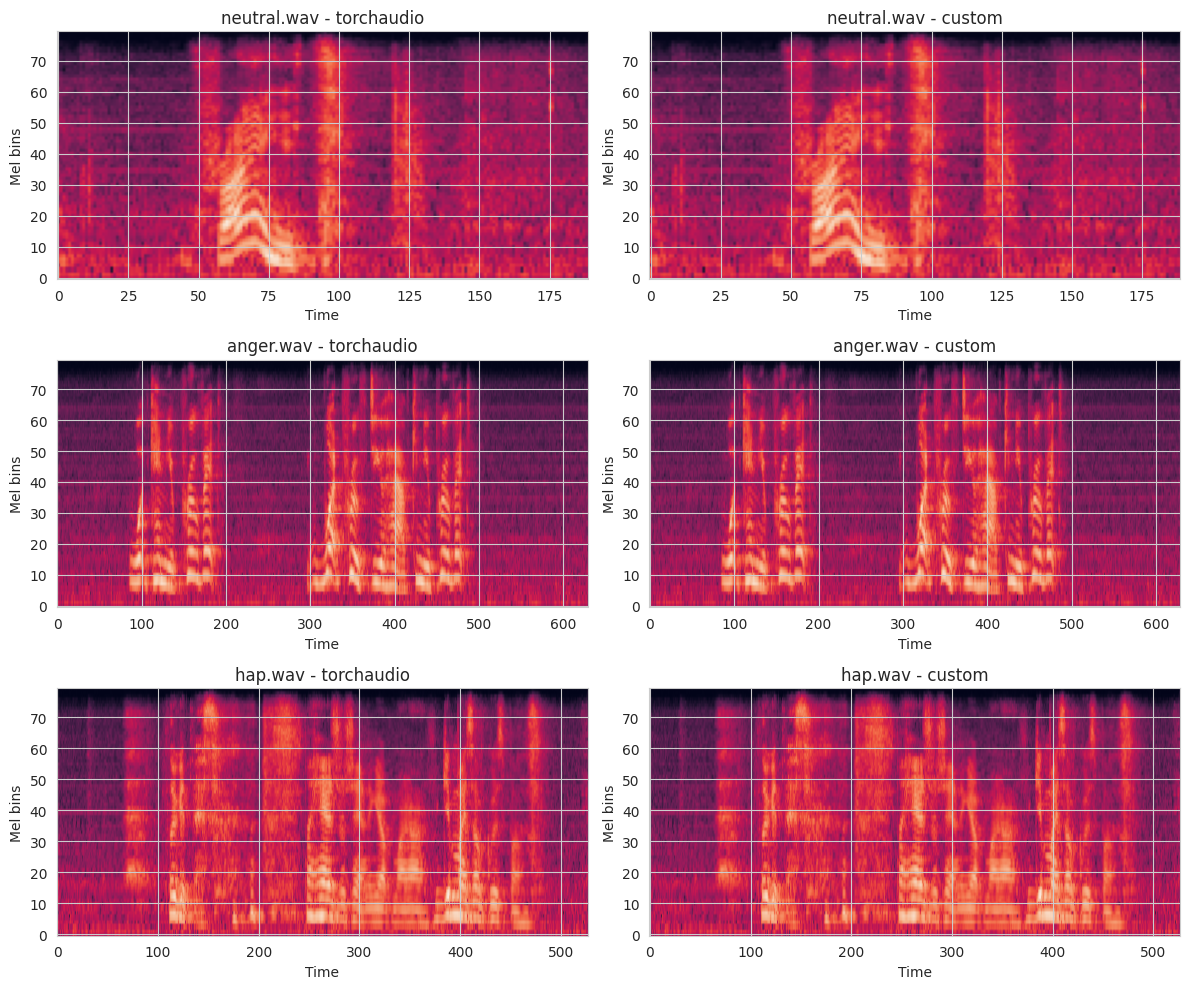

In [62]:
compare_spectrograms(files)

In [63]:
def check_assert(files):
    for file in files:
        signal, sr = torchaudio.load(file)

        ref = torch.log(melspec(signal) + 1e-6)
        custom = logmelbanks(signal)

        assert ref.shape == custom.shape
        assert torch.allclose(ref, custom)

        print(f'file {file},  max abs diff:', torch.max(torch.abs(ref - custom)))

In [64]:
check_assert(files)

file neutral.wav,  max abs diff: tensor(0.)
file anger.wav,  max abs diff: tensor(0.)
file hap.wav,  max abs diff: tensor(0.)
